In [2]:
# %% [markdown]
# 
# # Example of High Gamma Filter
# 
# Below is a code sample for extracting high gamma power from a raw data file, followed by permutation cluster stats on that high gamma power data
# 

# %% [markdown]
# ### working version 12/1/23

# %% [markdown]

# %% [markdown]
# use window stats with perm testing (0 to 0.5, 0.5 to 1, 0 to 1 sec relative to stim onset)

# %%
import sys
import os
print(sys.path)
# sys.path.append("C:/Users/jz421/Desktop/GlobalLocal/IEEG_Pipelines/") #need to do this cuz otherwise ieeg isn't added to path...comment out when running on cluster, but uncomment when running on pc.

# Get the absolute path to the directory containing the current script
# For GlobalLocal/src/analysis/preproc/make_epoched_data.py, this is GlobalLocal/src/analysis/preproc
try:
    # This will work if running as a .py script
    current_file_path = os.path.abspath(__file__)
    current_script_dir = os.path.dirname(current_file_path)
except NameError:
    # This will be executed if __file__ is not defined (e.g., in a Jupyter Notebook)
    # os.getcwd() often gives the directory of the notebook,
    # or the directory from which the Jupyter server was started.
    current_script_dir = os.getcwd()
# Navigate up three levels to get to the 'GlobalLocal' directory
project_root = os.path.abspath(os.path.join(current_script_dir, '..', '..', '..'))

# Add the 'GlobalLocal' directory to sys.path if it's not already there
if project_root not in sys.path:
    sys.path.insert(0, project_root) # insert at the beginning to prioritize it

import pandas as pd
import json
from statsmodels.stats.multitest import multipletests
from ieeg.navigate import channel_outlier_marker, trial_ieeg, crop_empty_data, \
    outliers_to_nan
from ieeg.io import raw_from_layout, get_data
from ieeg.timefreq.utils import crop_pad
from ieeg.timefreq import gamma
from ieeg.calc.scaling import rescale
import mne
import numpy as np
from ieeg.calc.stats import time_perm_cluster
from ieeg.calc.fast import mean_diff
from ieeg.viz.mri import gen_labels
import matplotlib.pyplot as plt
from mne.utils import fill_doc, verbose
import random
from contextlib import redirect_stdout

print(sys.path)
import pickle
from scipy.stats import ttest_ind
from functools import partial
from src.analysis.utils.general_utils import calculate_RTs, save_channels_to_file, save_sig_chans, load_sig_chans, identify_bad_channels_by_trial_nan_rate, impute_trial_nans_by_channel_mean, get_default_LAB_root
from src.analysis.utils.epoch_metadata_utils import make_metadata_from_event_names, add_previous_trial_info


['/hpc/home/jz421/miniconda3/envs/ieeg/lib/python311.zip', '/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11', '/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11/lib-dynload', '', '/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11/site-packages']
Qt5Agg backend not available, using default backend
Qt5Agg backend not available, using default backend
['/hpc/group/coganlab/jz421/GlobalLocal', '/hpc/home/jz421/miniconda3/envs/ieeg/lib/python311.zip', '/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11', '/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11/lib-dynload', '', '/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11/site-packages']


In [4]:
# Add this fixed version of crop_empty_data at the top of your script, after the imports
def crop_empty_data_fixed(raw, bound='boundary', start_pad="10s", end_pad="10s"):
    """Fixed version of crop_empty_data that handles MNE compatibility issues."""
    from ieeg.timefreq.utils import to_samples
    
    crop_list = []
    start_pad = to_samples(start_pad, raw.info['sfreq']) / raw.info['sfreq']
    end_pad = to_samples(end_pad, raw.info['sfreq']) / raw.info['sfreq']
    
    # split annotations into blocks
    annot = raw.annotations.copy()
    block_idx = [idx + 1 for idx, val in
                 enumerate(annot) if bound in val['description']]
    block_annot = [annot[i: j] for i, j in
                   zip([0] + block_idx, block_idx +
                       ([len(annot)] if block_idx[-1] != len(annot) else []))]
    
    for block_an in block_annot:
        # remove boundary events from annotations
        no_bound = None
        for an in block_an:
            if bound not in an['description']:
                # FIX: Handle the extras field compatibility issue
                an_dict = {}
                an_dict['onset'] = an['onset']
                an_dict['duration'] = an['duration']
                an_dict['description'] = an['description']
                if 'ch_names' in an:
                    an_dict['ch_names'] = an['ch_names']
                # Don't include 'extras' field to avoid compatibility issues
                
                if no_bound is None:
                    no_bound = mne.Annotations(**an_dict)
                else:
                    # Don't include orig_time in append
                    no_bound.append(onset=an_dict['onset'],
                                  duration=an_dict['duration'],
                                  description=an_dict['description'])
        
        # Skip if block is all boundary events
        if no_bound is None:
            continue
        
        # get start and stop time from raw.annotations onset attribute
        t_min = max(0, no_bound.onset[0] - start_pad)
        t_max = no_bound.onset[-1] + end_pad
        
        # create new cropped raw file
        crop_list.append(raw.copy().crop(tmin=t_min, tmax=t_max))
    
    return mne.concatenate_raws(crop_list)

In [5]:
# Determine LAB_root based on the operating system and environment

task='GlobalLocal'
HOME = os.path.expanduser("~")
USER = os.path.basename(HOME)

if os.name == 'nt':  # Windows
    LAB_root = os.path.join(HOME, "Box", "CoganLab")
elif sys.platform == 'darwin':  # macOS
    LAB_root = os.path.join(HOME, "Library", "CloudStorage", "Box-Box", "CoganLab")
else:  # Linux (cluster)
    # Check if we're on the cluster by looking for /cwork directory
    if os.path.exists(f"/cwork/{USER}"):
        LAB_root = f"/cwork/{USER}"
    else:
        # Fallback for other Linux systems
        LAB_root = os.path.join(HOME, "CoganLab")


sub = 'D0057'

layout = get_data(task, root=LAB_root)
filt = raw_from_layout(layout.derivatives['derivatives/clean'], subject=sub,
                    extension='.edf', desc='clean', preload=False)
save_dir = os.path.join(layout.root, 'derivatives', 'freqFilt', 'figs', sub)
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

Extracting EDF parameters from /cwork/jz421/BIDS-1.1_GlobalLocal/BIDS/derivatives/clean/sub-D0057/ieeg/sub-D0057_task-GlobalLocal_acq-01_run-01_desc-clean_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /cwork/jz421/BIDS-1.1_GlobalLocal/BIDS/derivatives/clean/sub-D0057/ieeg/sub-D0057_task-GlobalLocal_acq-01_run-01_desc-clean_events.tsv.
Reading channel info from /cwork/jz421/BIDS-1.1_GlobalLocal/BIDS/derivatives/clean/sub-D0057/ieeg/sub-D0057_task-GlobalLocal_acq-01_run-01_desc-clean_channels.tsv.
Reading electrode coords from /cwork/jz421/BIDS-1.1_GlobalLocal/BIDS/derivatives/clean/sub-D0057/ieeg/sub-D0057_acq-01_space-ACPC_electrodes.tsv.
Extracting EDF parameters from /cwork/jz421/BIDS-1.1_GlobalLocal/BIDS/derivatives/clean/sub-D0057/ieeg/sub-D0057_task-GlobalLocal_acq-01_run-02_desc-clean_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /cwork/jz421/B

/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11/site-packages/ieeg/io.py:278: RuntimeWarning: The number of channels in the channels.tsv sidecar file (179) does not match the number of channels in the raw data file (178). Will not try to set channel names.
  new_raw = read_raw_bids(bids_path=BIDS_path, verbose=verbose)
/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11/site-packages/ieeg/io.py:278: RuntimeWarning: Cannot set channel type for the following channels, as they are missing in the raw data: Trigger
  new_raw = read_raw_bids(bids_path=BIDS_path, verbose=verbose)
/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11/site-packages/ieeg/io.py:278: RuntimeWarning: Omitted 228 annotation(s) that were outside data range.
  new_raw = read_raw_bids(bids_path=BIDS_path, verbose=verbose)
/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11/site-packages/ieeg/io.py:278: RuntimeWarning: The number of channels in the channels.tsv sidecar file (179) does not match the number of channels 

Extracting EDF parameters from /cwork/jz421/BIDS-1.1_GlobalLocal/BIDS/derivatives/clean/sub-D0057/ieeg/sub-D0057_task-GlobalLocal_acq-01_run-04_desc-clean_ieeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /cwork/jz421/BIDS-1.1_GlobalLocal/BIDS/derivatives/clean/sub-D0057/ieeg/sub-D0057_task-GlobalLocal_acq-01_run-04_desc-clean_events.tsv.
Reading channel info from /cwork/jz421/BIDS-1.1_GlobalLocal/BIDS/derivatives/clean/sub-D0057/ieeg/sub-D0057_task-GlobalLocal_acq-01_run-04_desc-clean_channels.tsv.
Reading electrode coords from /cwork/jz421/BIDS-1.1_GlobalLocal/BIDS/derivatives/clean/sub-D0057/ieeg/sub-D0057_acq-01_space-ACPC_electrodes.tsv.


/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11/site-packages/ieeg/io.py:278: RuntimeWarning: Omitted 226 annotation(s) that were outside data range.
  new_raw = read_raw_bids(bids_path=BIDS_path, verbose=verbose)
/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11/site-packages/ieeg/io.py:278: RuntimeWarning: The number of channels in the channels.tsv sidecar file (179) does not match the number of channels in the raw data file (178). Will not try to set channel names.
  new_raw = read_raw_bids(bids_path=BIDS_path, verbose=verbose)
/hpc/home/jz421/miniconda3/envs/ieeg/lib/python3.11/site-packages/ieeg/io.py:278: RuntimeWarning: Cannot set channel type for the following channels, as they are missing in the raw data: Trigger
  new_raw = read_raw_bids(bids_path=BIDS_path, verbose=verbose)


In [ ]:
print("Use my new crop empty data function that gets rid of the mne annotations extras dict")
good = crop_empty_data_fixed(filt)
# %%

print(f"good channels before dropping bads: {len(good.ch_names)}")
print(f"filt channels before dropping bads: {len(filt.ch_names)}")
all_channels_before_marker = good.ch_names.copy()
channels_to_drop = []

good.info['bads'] = channel_outlier_marker(good, 3, 2)
marker_bad_channels = good.info['bads'].copy()

print("Bad channels in 'good':", good.info['bads'])

filt.drop_channels(marker_bad_channels)  # this has to come first cuz if you drop from good first, then good.info['bads'] is just empty
good.drop_channels(marker_bad_channels)

print("Bad channels in 'good' after dropping once:", good.info['bads'])

print(f"good channels after dropping bads: {len(good.ch_names)}")
print(f"filt channels after dropping bads: {len(filt.ch_names)}")

good.load_data()



Use my new crop empty data function that gets rid of the mne annotations extras dict
good channels before dropping bads: 178
filt channels before dropping bads: 178
outlier round 1 channels: ['RAMT8']
outlier round 2 channels: ['RAMT8', 'RPI16']
outlier round 2 channels: ['RAMT8', 'RPI16', 'LAMT12']
Bad channels in 'good': ['RAMT8', 'RPI16', 'LAMT12']
Bad channels in 'good' after dropping once: []
good channels after dropping bads: 175
filt channels after dropping bads: 175
Reading 0 ... 6198083  =      0.000 ...  3026.408 secs...


NameError: name 'channels' is not defined

In [7]:
# If channels is None, use all channels

channels = good.ch_names
# Validate the provided channels
invalid_channels = [ch for ch in channels if ch not in good.ch_names]
if invalid_channels:
    raise ValueError(
            f"The following channels are not valid: {invalid_channels}")

    # Use only the specified channels
    good.pick_channels(channels)

ch_type = filt.get_channel_types(only_data_chs=True)[0]
good.set_eeg_reference(ref_channels="average", ch_type=ch_type)

Applying average reference.
Applying a custom ('sEEG',) reference.


<RawEDF | sub-D0057_task-GlobalLocal_acq-01_run-01_desc-clean_ieeg.edf, 175 x 6198084 (3026.4 s), ~8.08 GiB, data loaded>

In [ ]:
trials = trial_ieeg(good, 'Stimulus', [-2.5, 3], preload=True, reject_by_annotation=False)

# Now extract gamma and proceed with analysis

HG_ev1_filterbank_hilbert = gamma.extract(trials, passband=(4, 8), copy=True, n_jobs=1)


Used Annotations descriptions: [np.str_('1'), np.str_('2'), np.str_('Response/c25.0/n25.0/BigLetters/SmallLetters/Taskl/TargetLetters/Responded1.0/ParticipantResponse115.0/CorrectResponse115.0/TrialCount225.0/BlockTrialCount1.0/ReactionTime2149.0/Accuracy1.0/D57'), np.str_('Response/c25.0/r25.0/BigLetterh/SmallLetterh/Taskg/TargetLetterh/Responded1.0/ParticipantResponse114.0/CorrectResponse114.0/TrialCount227.0/BlockTrialCount3.0/ReactionTime883.0/Accuracy1.0/D57'), np.str_('Response/c25.0/r25.0/BigLetterh/SmallLetterh/Taskg/TargetLetterh/Responded1.0/ParticipantResponse114.0/CorrectResponse114.0/TrialCount228.0/BlockTrialCount4.0/ReactionTime766.0/Accuracy1.0/D57'), np.str_('Response/c25.0/r25.0/BigLetterh/SmallLetterh/Taskg/TargetLetterh/Responded1.0/ParticipantResponse114.0/CorrectResponse114.0/TrialCount241.0/BlockTrialCount17.0/ReactionTime499.0/Accuracy1.0/D57'), np.str_('Response/c25.0/r25.0/BigLetterh/SmallLetterh/Taskg/TargetLetterh/Responded1.0/ParticipantResponse114.0/Correc

100%|██████████| 449/449 [08:14<00:00,  1.10s/it]


NameError: name 'passband' is not defined

In [ ]:
HG_ev1_bandpass = trials.copy().filter(4, 8, method='fir', fir_design='firwin')
HG_ev1_bandpass.apply_hilbert(envelope=True) # get real signal only - if you set envelope=False, you can grab the complex signal and then do np.angle(HG_ev1._data) to get the phase. But make sure to do that before decimation cuz that will mess up the phase calculation.

Setting up band-pass filter from 4 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 3381 samples (1.651 s)



<Epochs | 449 events (all good), -2.5 – 3 s (baseline off), ~6.60 GiB, data loaded,
 np.str_('Stimulus/c25.0/n25.0/BigLetters/SmallLetters/Taskl/TargetLetters/Responded1.0/ParticipantResponse115.0/CorrectResponse115.0/TrialCount225.0/BlockTrialCount1.0/ReactionTime2149.0/Accuracy1.0/D57'): 1
 np.str_('Stimulus/c25.0/r25.0/BigLetterh/SmallLetterh/Taskg/TargetLetterh/Responded1.0/ParticipantResponse114.0/CorrectResponse114.0/TrialCount227.0/BlockTrialCount3.0/ReactionTime883.0/Accuracy1.0/D57'): 1
 np.str_('Stimulus/c25.0/r25.0/BigLetterh/SmallLetterh/Taskg/TargetLetterh/Responded1.0/ParticipantResponse114.0/CorrectResponse114.0/TrialCount228.0/BlockTrialCount4.0/ReactionTime766.0/Accuracy1.0/D57'): 1
 np.str_('Stimulus/c25.0/r25.0/BigLetterh/SmallLetterh/Taskg/TargetLetterh/Responded1.0/ParticipantResponse114.0/CorrectResponse114.0/TrialCount241.0/BlockTrialCount17.0/ReactionTime499.0/Accuracy1.0/D57'): 1
 np.str_('Stimulus/c25.0/r25.0/BigLetterh/SmallLetterh/Taskg/TargetLetterh/Responded1.0/ParticipantResponse114.0/CorrectResponse114.0/TrialCount257.0/BlockTrialCount33.0/ReactionTime616.0/Accuracy1.0/D57'): 1
 np.str_('Stimulus/c25.0/r25.0/BigLetterh/SmallLetterh/Taskg/TargetLetterh/Responded1.0/ParticipantResponse114.0/CorrectResponse114.0/TrialCount258.0/BlockTrialCount34.0/ReactionTime650.0/Accuracy1.0/D57'): 1
 np.str_('Stimulus/c25.0/r25.0/BigLetterh/SmallLetterh/Taskg/TargetLetterh/Responded1.0/ParticipantResponse114.0/CorrectResponse114.0/TrialCount267.0/BlockTrialCount43.0/ReactionTime833.0/Accuracy1.0/D57'): 1
 np.str_('Stimulus/c25.0/r25.0/BigLetterh/SmallLetterh/Taskg/TargetLetterh/Responded1.0/ParticipantResponse114.0/CorrectResponse114.0/TrialCount268.0/BlockTrialCount44.0/ReactionTime566.0/Accuracy1.0/D57'): 1
 np.str_('Stimulus/c25.0/r25.0/BigLetterh/SmallLetterh/Taskg/TargetLetterh/Responded1.0/ParticipantResponse114.0/CorrectResponse114.0/TrialCount271.0/BlockTrialCount47.0/ReactionTime833.0/Accuracy1.0/D57'): 1
 np.str_('Stimulus/c25.0/r25.0/BigLetterh/SmallLetterh/Taskg/TargetLetterh/Responded1.0/ParticipantResponse114.0/CorrectResponse114.0/TrialCount274.0/BlockTrialCount50.0/ReactionTime1366.0/Accuracy1.0/D57'): 1
 and 438 more events ...>

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


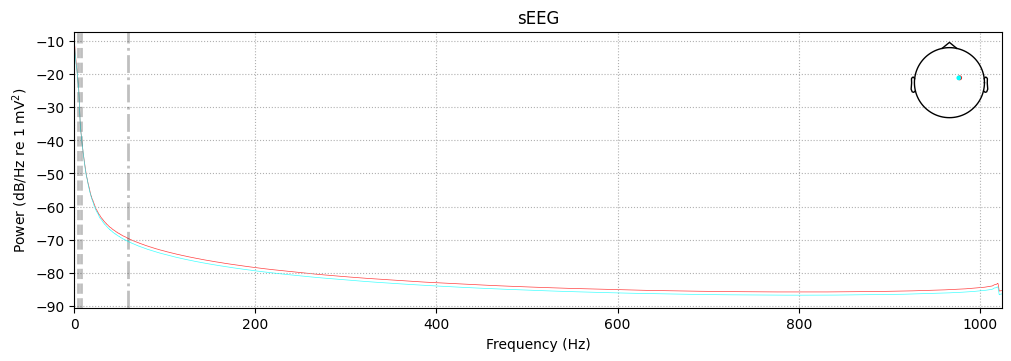

In [16]:
trials.compute_psd(picks=[1, 2], n_jobs=1).plot()
HG_ev1_filterbank_hilbert.compute_psd(picks=[1, 2], n_jobs=1).plot()
HG_ev1_bandpass.compute_psd(picks=[1, 2], n_jobs=1).plot()

Setting up band-pass filter from 4 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 3381 samples (1.651 s)



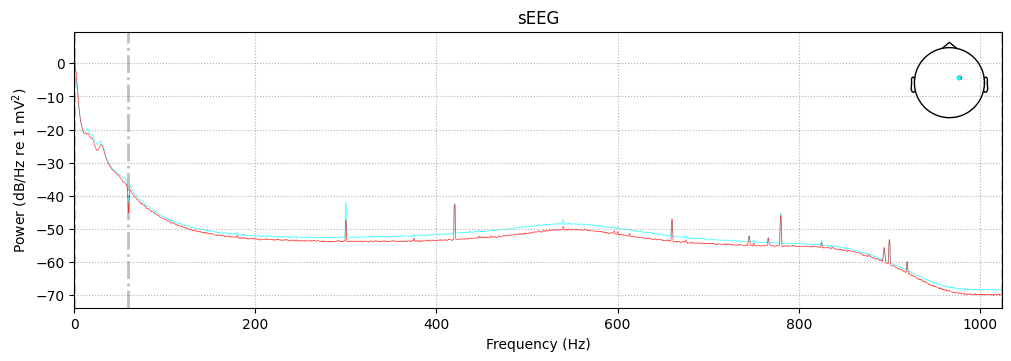

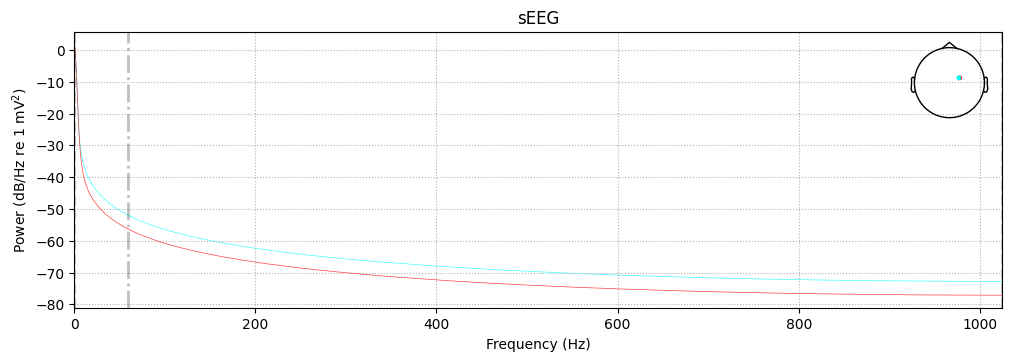

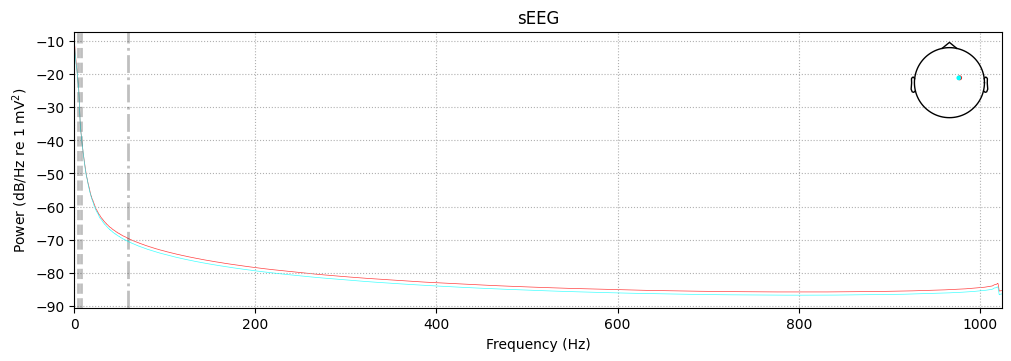

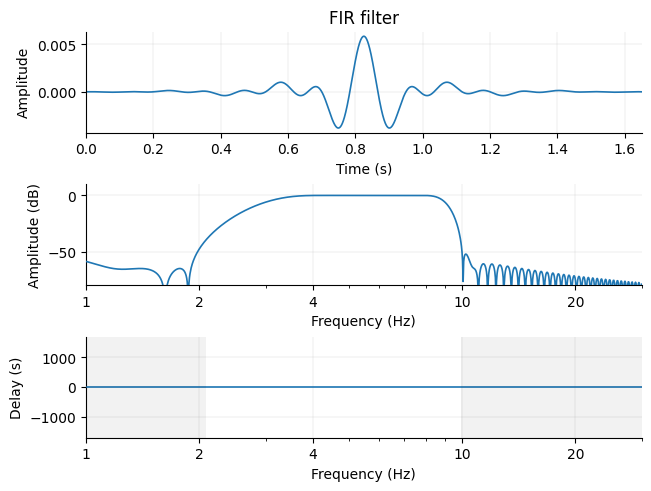

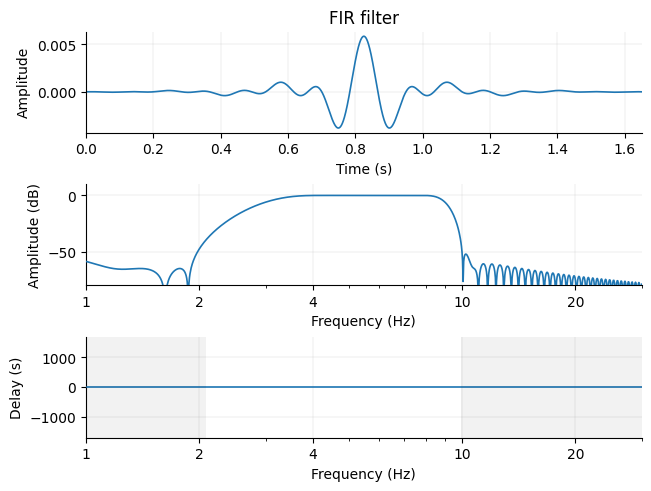

In [18]:
filter_params = mne.filter.create_filter(
    trials.get_data(), 2048, l_freq=4, h_freq=8,
    method='fir', fir_design='firwin'
)

mne.viz.plot_filter(filter_params, 2048, flim=(1,30))


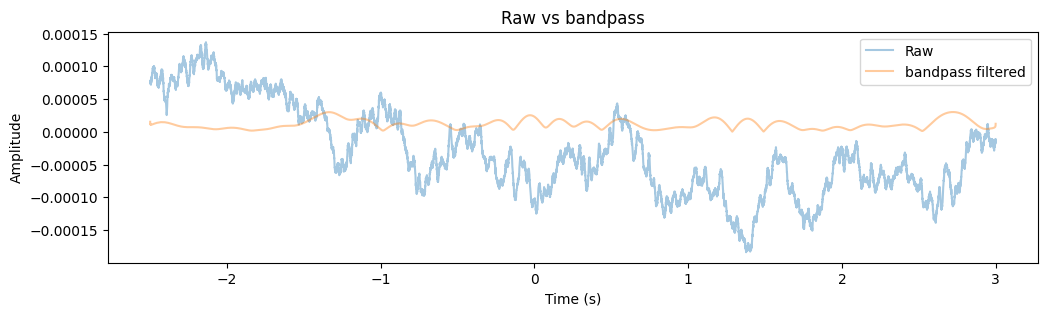

In [19]:
ch = 0
trial = 0
times = trials.times

fig, ax = plt.subplots(figsize=(12,3))
ax.plot(times, trials.get_data()[trial, ch, :], alpha=0.4, label='Raw')
ax.plot(times, HG_ev1_bandpass.get_data()[trial, ch, :], alpha=0.4, label='bandpass filtered')
ax.legend()
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title('Raw vs bandpass')
plt.show()

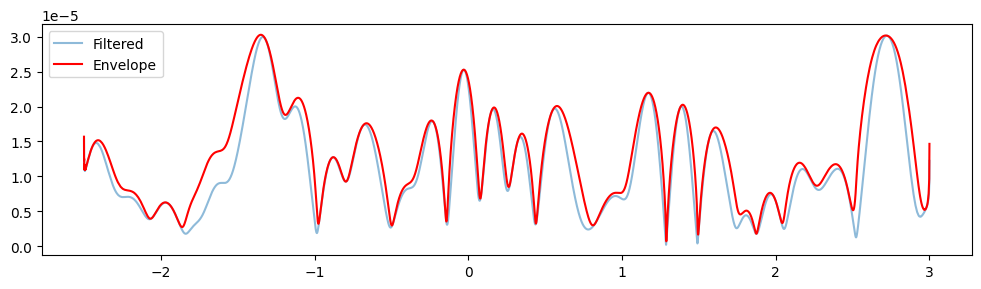

In [20]:
filtered = HG_ev1_bandpass.get_data()[trial, ch, :]
# envelope was already computed, but for visualization:
from scipy.signal import hilbert
envelope = np.abs(hilbert(filtered))

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(HG_ev1_bandpass.times, filtered, alpha=0.5, label='Filtered')
ax.plot(HG_ev1_bandpass.times, envelope, color='red', label='Envelope')
ax.legend()
plt.show()

In [25]:
from scipy.signal import freqz, welch
sfreq=2048
# get the filter's ideal frequency response
filt = mne.filter.create_filter(
    None, sfreq, l_freq=4, h_freq=8,
    method='fir', fir_design='firwin'
)
w, h = freqz(filt, worN=8192, fs=sfreq)
filter_gain_db = 20 * np.log10(np.abs(h))

# get actual PSD before and after filtering
raw_data = trials.get_data()[0, 0, :]       # one trial, one channel
filt_data = HG_ev1_bandpass.get_data()[0, 0, :]

f_raw, psd_raw = welch(raw_data, fs=sfreq, nperseg=1024)
f_filt, psd_filt = welch(filt_data, fs=sfreq, nperseg=1024)

# compute the empirical gain: ratio of filtered to raw PSD, in dB
empirical_gain_db = 10 * np.log10(psd_filt / psd_raw)

gains = []
for trial in range(min(20, len(trials))):
    for ch in range(min(5, len(trials.ch_names))):
        _, psd_r = welch(trials.get_data()[trial, ch, :], 
                         fs=sfreq, nperseg=1024)
        _, psd_f = welch(HG_ev1_bandpass.get_data()[trial, ch, :], 
                         fs=sfreq, nperseg=1024)
        gains.append(10 * np.log10(psd_f / psd_r))

mean_gain = np.mean(gains, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(w, filter_gain_db, label='Ideal filter response', color='black')
ax.plot(f_raw, mean_gain, label='mean gain', 
        color='tab:blue', alpha=0.7)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Gain (dB)')
ax.set_xlim(0, 30)
ax.set_ylim(-60, 5)
ax.axvline(4, color='red', linestyle='--', alpha=0.3)
ax.axvline(8, color='red', linestyle='--', alpha=0.3)
ax.legend()
ax.set_title('Ideal vs empirical filter gain')
plt.show()

No data specified. Sanity checks related to the length of the signal relative to the filter order will be skipped.
Setting up band-pass filter from 4 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 3381 samples (1.651 s)



KeyboardInterrupt: 

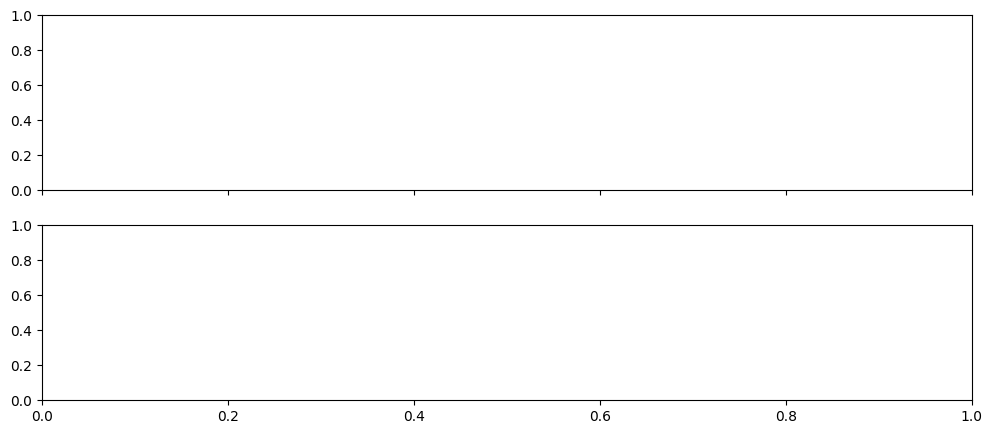

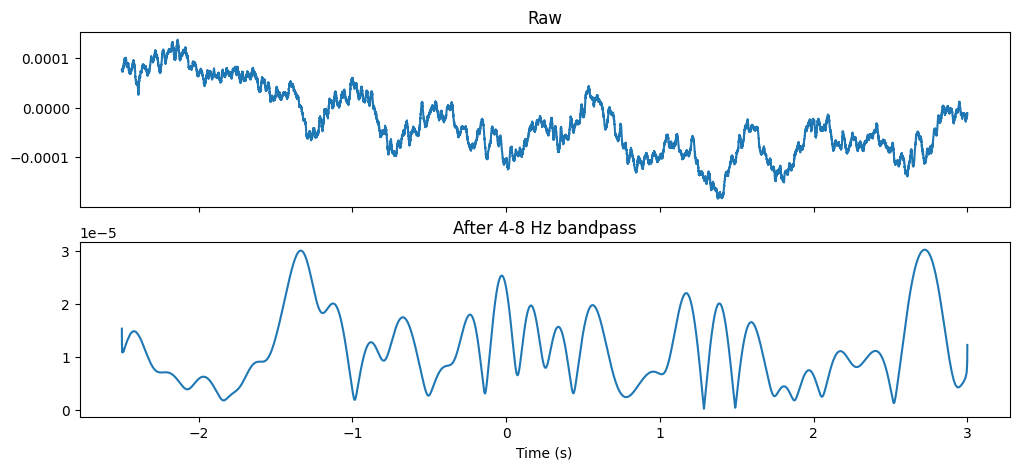

In [27]:
ch, trial = 0, 0
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(trials.times, trials.get_data()[trial, ch, :])
axes[0].set_title('Raw')

axes[1].plot(HG_ev1_bandpass.times, HG_ev1_bandpass.get_data()[trial, ch, :])
axes[1].set_title('After 4-8 Hz bandpass')
axes[1].set_xlabel('Time (s)')
plt.show()

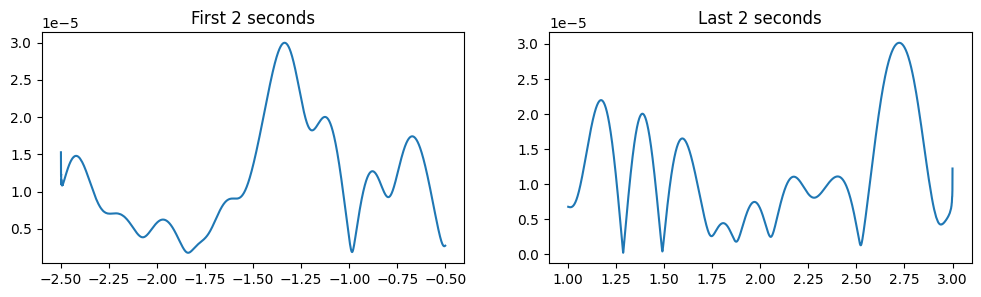

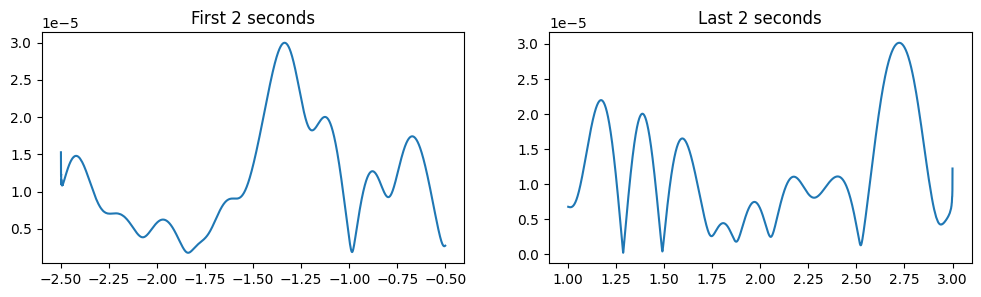

In [30]:
ch, trial = 0, 0
data = HG_ev1_bandpass.get_data()[trial, ch, :]

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(HG_ev1_bandpass.times[:int(2*sfreq)], data[:int(2*sfreq)])
axes[0].set_title('First 2 seconds')

axes[1].plot(HG_ev1_bandpass.times[-int(2*sfreq):], data[-int(2*sfreq):])
axes[1].set_title('Last 2 seconds')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
for trial in range(min(10, len(HG_ev1_bandpass))):
    ax.plot(HG_ev1_bandpass.times, HG_ev1_bandpass.get_data()[trial, ch, :], alpha=0.3)
ax.set_xlabel('Time (s)')
ax.set_title('10 trials overlaid, one channel')